### Overview
In this notebook, we will be looking at sample outputs of PandasAgent from part 1. Main objective is to make the agent answer any question related to the dataframe and help the users to analyze the dataframe.

There are wide-variety of queries can be asked to our agent
1. Simple queries - ex: how many rows and columns present in the data
2. Generic queries - ex: what is this dataframe about?
3. Out-of-Data Queries - queries that are not related to this dataframe - its important that we avoid these scenarios where agent answer these questions
4. Data Analysis Queries - These are deterministic queries but are complex than simple queries. ex: plot the average fire size for each fire size class
5. Complex Queries - These are very hard to answer and evaluate. Sometimes agents make their own assumptions while doing the analysis. its important we give enough instructions/demonstrations to steer the agent analysis. ex: which state is least fire-prone? - "here how do we quantify fire-prone?"

In [1]:
import sys
sys.path.append(".././part1")

In [3]:
import pandas as pd
df = pd.read_csv("./data/sample_data.csv")
print(df.shape)
df.head(1)

(1000, 39)


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
0,1172623,1423728,MSARCH_44025,NONFED,ST-MSMSS,ST/C&L,USMSMSS,Mississippi Forestry Commission,MSMSS,Mississippi Forestry Commission,...,D,31.064108,-89.685894,14.0,MISSING/NOT SPECIFIED,MS,Marion,91.0,Marion,b'\x00\x01\xad\x10\x00\x00\x80\xd0\xd5\xb1\xe5...


In [4]:
from pandas_agent import PandasAgent
pd_agent = PandasAgent(df)

### Simple Queries

In [7]:
pd_agent.run("How many rows are in the dataframe?")



> Entering new AgentExecutor chain...
Thought: I can use the `shape` attribute of the dataframe to find the number of rows.
Action: python_repl_ast
Action Input: df.shape(1000, 39)The number of rows in the dataframe is 1000.
Final Answer: 1000

> Finished chain.


'1000'

In [16]:
pd_agent.run("How many unique values in the source system are in the dataframe?")



> Entering new AgentExecutor chain...
Thought: I can use the nunique() function in pandas to find the number of unique values in the 'SOURCE_SYSTEM' column.
Action: python_repl_ast
Action Input: df['SOURCE_SYSTEM'].nunique()33I now know the final answer
Final Answer: There are 33 unique values in the 'SOURCE_SYSTEM' column in the dataframe.

> Finished chain.


"There are 33 unique values in the 'SOURCE_SYSTEM' column in the dataframe."

In [18]:
pd_agent.run("How many unique values in the fire size class and what are they")



> Entering new AgentExecutor chain...
Thought: I can use the `nunique()` function to find the number of unique values and the `unique()` function to find the actual unique values in the 'FIRE_SIZE_CLASS' column of the dataframe.
Action: python_repl_ast
Action Input: df['FIRE_SIZE_CLASS'].nunique(), df['FIRE_SIZE_CLASS'].unique()(6, array(['D', 'B', 'A', 'C', 'E', 'F'], dtype=object))I now know the final answer
Final Answer: There are 6 unique values in the 'FIRE_SIZE_CLASS' column: 'D', 'B', 'A', 'C', 'E', and 'F'

> Finished chain.


"There are 6 unique values in the 'FIRE_SIZE_CLASS' column: 'D', 'B', 'A', 'C', 'E', and 'F'"

### Generic Query

Look how agent was able to answer this query based on few observations from the data itself

In [8]:
pd_agent.run("what information dataframe contains? is it related to some topic?")



> Entering new AgentExecutor chain...
Thought: I can check the column names to see what kind of information the dataframe contains.
Action: python_repl_ast
Action Input: df.columnsIndex(['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM',
       'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME',
       'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY',
       'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE',
       'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE',
       'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY',
       'FIPS_CODE', 'FIPS_NAME', 'Shape'],
      dtype='object')

'The dataframe contains information related to fires, including details such as fire ID, reporting agency, location, cause of the fire, and fire size. It seems to be related to the topic of fire incidents and management.`'

### Out-of-Data Queries

In [19]:
pd_agent.run("Do you know anything about the world?") # question outside the dataframe



> Entering new AgentExecutor chain...
Thought: This question is not related to the dataframe, so I cannot answer it using the dataframe.
Final Answer: I cannot answer this question using the dataframe.

> Finished chain.


'I cannot answer this question using the dataframe.'

### Data Analysis queries

In [20]:
# agent was able to rightly identify definition of "useless" is based on NaN values
pd_agent.run("Which columns are useless for any data analysis?")



> Entering new AgentExecutor chain...
Thought: I should look for columns that have mostly NaN values or contain information that is not relevant for data analysis.
Action: python_repl_ast
Action Input: df.isnull().sum()OBJECTID                        0
FOD_ID                          0
FPA_ID                          0
SOURCE_SYSTEM_TYPE              0
SOURCE_SYSTEM                   0
NWCG_REPORTING_AGENCY           0
NWCG_REPORTING_UNIT_ID          0
NWCG_REPORTING_UNIT_NAME        0
SOURCE_REPORTING_UNIT           0
SOURCE_REPORTING_UNIT_NAME      0
LOCAL_FIRE_REPORT_ID          778
LOCAL_INCIDENT_ID             448
FIRE_CODE                     836
FIRE_NAME                     509
ICS_209_INCIDENT_NUMBER       987
ICS_209_NAME                  987
MTBS_ID                       996
MTBS_FIRE_NAME                996
COMPLEX_NAME                  999
FIRE_YEAR                       0
DISCOVERY_DATE                  0
DISCOVERY_DOY                   0
DISCOVERY_TIME                5

'The columns `LOCAL_FIRE_REPORT_ID`, `LOCAL_INCIDENT_ID`, `FIRE_CODE`, `FIRE_NAME`, `ICS_209_INCIDENT_NUMBER`, `ICS_209_NAME`, `MTBS_ID`, `MTBS_FIRE_NAME`, `COMPLEX_NAME`, `DISCOVERY_TIME`, `CONT_DATE`, `CONT_DOY`, `CONT_TIME`, `COUNTY`, and `FIPS_CODE` are potentially useless for data analysis.'



> Entering new AgentExecutor chain...
Thought: I need to calculate the average fire size for each fire size class and then create a bar plot.
Action: python_repl_ast
Action Input: df.groupby('FIRE_SIZE_CLASS')['FIRE_SIZE'].mean().plot(kind='bar')Axes(0.125,0.11;0.775x0.77)I now know the final answer
Final Answer: The bar plot of the average fire size for each fire size class has been created.

> Finished chain.


'The bar plot of the average fire size for each fire size class has been created.'

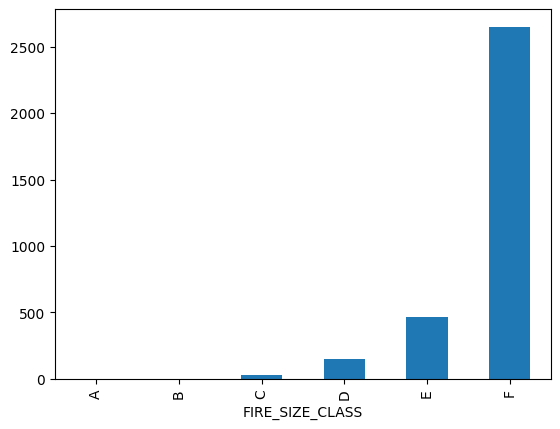

In [ ]:
# even plots can be made through this agent
pd_agent.run("Plot the average fire size for fire size class?")



> Entering new AgentExecutor chain...
Thought: I can use the pandas groupby function to group the data by owner entity and then calculate the average fire size for each group.
Action: python_repl_ast
Action Input: df.groupby('OWNER_DESCR')['FIRE_SIZE'].mean().plot(kind='bar')Axes(0.125,0.11;0.775x0.77)I now know the final answer
Final Answer: The figure shows the average fire size for each owner entity.

> Finished chain.


'The figure shows the average fire size for each owner entity.'

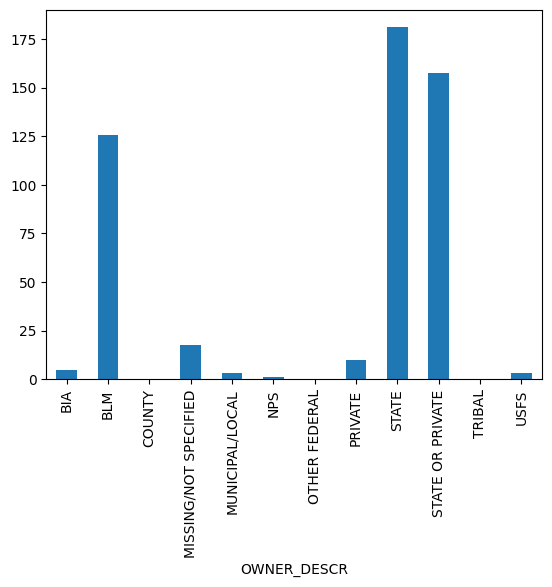

In [15]:
pd_agent.run("Draw a figure to show the average fire size for each owner entity?")

### Complex Queries

In [21]:
pd_agent.run("Any relationship between fire size and fire size class?")



> Entering new AgentExecutor chain...
Thought: I can use the `groupby` function to group the data by fire size class and then calculate the average fire size for each class.
Action: python_repl_ast
Action Input: df.groupby('FIRE_SIZE_CLASS')['FIRE_SIZE'].mean()FIRE_SIZE_CLASS
A       0.117964
B       2.135181
C      29.800254
D     149.088000
E     465.197500
F    2647.000000
Name: FIRE_SIZE, dtype: float64The average fire size increases as the fire size class increases. 
Final Answer: There is a positive relationship between fire size and fire size class, as the average fire size increases with each higher fire size class.

> Finished chain.


'There is a positive relationship between fire size and fire size class, as the average fire size increases with each higher fire size class.'

In [22]:
pd_agent.run("Which state is least fire-prone?")



> Entering new AgentExecutor chain...
Thought: I need to calculate the total number of fires for each state and then find the state with the least number of fires.
Action: python_repl_ast
Action Input: df['STATE'].value_counts()STATE
CA    105
GA     78
TX     76
NC     65
SC     47
FL     45
AZ     44
AL     40
OR     40
NY     39
MS     39
AR     28
OK     25
MN     23
MT     22
UT     22
TN     21
SD     20
CO     17
WA     17
ID     16
NJ     14
VA     14
KY     13
PR     13
WI     13
NM     10
WV     10
MI      9
HI      9
MO      9
NV      8
AK      7
WY      6
LA      6
ND      6
ME      5
OH      4
IL      3
PA      3
IA      2
IN      2
KS      2
NE      1
MA      1
MD      1
Name: count, dtype: int64I now know the final answer
Final Answer: The state of Maryland is the least fire-prone with only 1 fire.

> Finished chain.


'The state of Maryland is the least fire-prone with only 1 fire.'

In [23]:
# we helped agent to think in a certain way - this can be done through prompt engineering
pd_agent.run("Which state is least fire-prone? I want to define fire-prone in-terms of number of fires, fire size and duration")



> Entering new AgentExecutor chain...
Thought: I can calculate the fire-proneness of each state by considering the number of fires, average fire size, and average duration of fires in each state.
Action: python_repl_ast
Action Input: 
```python
# Grouping the dataframe by state and calculating the number of fires, average fire size, and average duration
fire_proneness = df.groupby('STATE').agg({'FIRE_SIZE': 'mean', 'FIRE_YEAR': 'count', 'DISCOVERY_DOY': 'mean'})
# Sorting the states by fire proneness
fire_proneness = fire_proneness.sort_values(by=['FIRE_SIZE', 'FIRE_YEAR', 'DISCOVERY_DOY'], ascending=[True, True, True])
fire_proneness
```        FIRE_SIZE  FIRE_YEAR  DISCOVERY_DOY
STATE                                      
MA       0.010000          1     248.000000
NE       0.100000          1     206.000000
WA       0.430588         17     206.294118
WI       0.606923         13     134.230769
NJ       0.625000         14     178.500000
OR       0.652500         40     203.975000


'Massachusetts (MA) is the least fire-prone state.'

In [28]:
# if we have given MLModelling as a tool, agent would be able to build a ML model with just prompting - AutoML models
pd_agent.run("Given the size, location and date, can we predict the cause of a fire wildfire?")



> Entering new AgentExecutor chain...
Thought: We can use machine learning algorithms to predict the cause of a wildfire based on the size, location, and date.
Action: python_repl_ast
Action Input: df.info()<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   OBJECTID                    1000 non-null   int64  
 1   FOD_ID                      1000 non-null   int64  
 2   FPA_ID                      1000 non-null   object 
 3   SOURCE_SYSTEM_TYPE          1000 non-null   object 
 4   SOURCE_SYSTEM               1000 non-null   object 
 5   NWCG_REPORTING_AGENCY       1000 non-null   object 
 6   NWCG_REPORTING_UNIT_ID      1000 non-null   object 
 7   NWCG_REPORTING_UNIT_NAME    1000 non-null   object 
 8   SOURCE_REPORTING_UNIT       1000 non-null   object 
 9   SOURCE_REPORTING_UNIT_NAME  1000 non-null   object 
 

'Yes, we can predict the cause of a wildfire using machine learning algorithms and the data available in the dataframe.'